In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from scipy import stats

df = sns.load_dataset('titanic')
df.to_csv('../data/titanic.csv', index=False)

Посчитаю разницу доли выживших по полу

In [2]:
s_main = df[df['sex'] == 'female']['survived'].mean() - df[df['sex'] == 'male']['survived'].mean()
print(s_main)

0.5531300709799203


Сделаю перемешаю полы в выборке и посчитаю разницу снова

Думаю раз перемешается случайно, то разница будет примерно 0

In [3]:
sex_values = df['sex'].values
df['sex'] = np.random.permutation(sex_values)
print(df[df['sex'] == 'female']['survived'].mean() - df[df['sex'] == 'male']['survived'].mean())

0.017088167437547652


Результат получился около нуля так как при перемешивание у мужчины попасть в ячейку выжившего столько же шанса как и у женщины

Повторю это 10000 раз и построю гистограмму

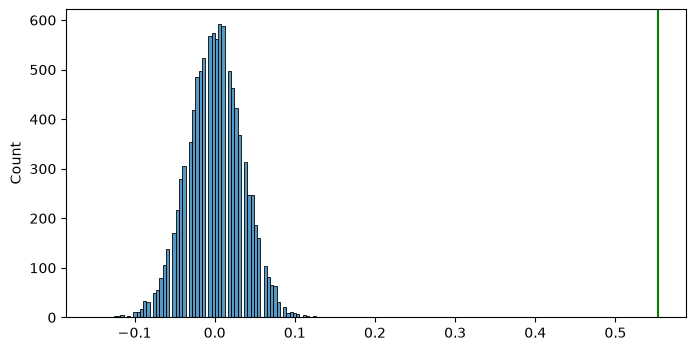

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
lines = []
survived_values = df['survived'].values

for _ in range(10000):
    shuffled_sex = np.random.permutation(sex_values)
    s = survived_values[shuffled_sex == 'female'].mean() - survived_values[shuffled_sex == 'male'].mean()
    lines.append(s)

sns.histplot(data=lines, ax=ax)
ax.axvline(x=s_main, color='green')

Посчитаю долю разницы средний тех, что по модулю не меньше оригинальной, хотя по картинке видно что это ноль, но всё же сверюсь по числам

In [5]:
print(sum(1 for x in lines if abs(x) >= s_main) / 10000)

0.0


p получилось меньше 0.0001, значит можно опровергнуть гипотезу о том что пол не влияет на выживаемость

Теперь посчитаю то же самое только для чётности индексов

In [6]:
y_main = df.iloc[::2]['survived'].mean() - df.iloc[1::2]['survived'].mean()
print(y_main)

-0.05922305638131703


получилось почти ноль

теперь посчитаю это 10000 и построю гистограмму думаю p получится большим, а как гистограмма будет выглядеть я не могу представить

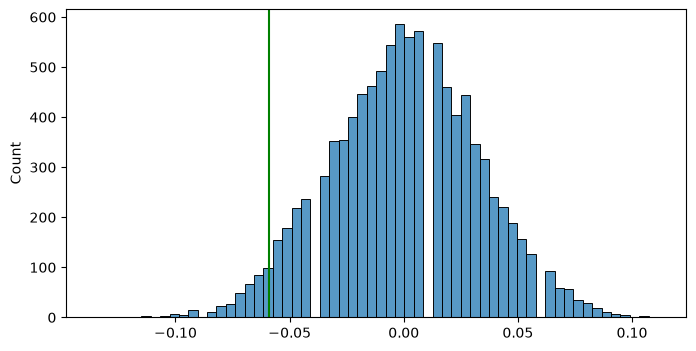

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
lines = []

for _ in range(10000):
    shuffled_survived = df['survived'].sample(frac=1).reset_index(drop=True)
    diff = shuffled_survived.iloc[::2].mean() - shuffled_survived.iloc[1::2].mean()
    lines.append(diff)

sns.histplot(data=lines, ax=ax)
ax.axvline(x=y_main, color='green')

In [8]:
print(sum(1 for x in lines if abs(x) >= abs(y_main)) / 10000)

0.0707


здесь p больше 0.05, что не позволяет нам отвергнуть нулевую гипотезу о том что индекс не влияет на выживаемость

1. Сделай 200 бессмысленных разбиений пассажиров — например, каждый раз случайно делить их на две группы жребием, никак не связанным с данными.

2. Для каждого посчитай p-value перестановочным тестом. Чтобы не ждать вечность, хватит 500 перестановок на каждый тест.

3. Посчитай, у скольких из 200 вышло p < 0.05. Предскажи число до запуска.

4. Построй гистограмму всех 200 p-value. Предскажи её форму: будет ли она где-то сгущаться?

думаю p которые < 0.05 будет 5% из 200, то есть где то 10 
думаю на гистограме будет симметричная волна или что то типа прямоугольника

повторить 200 раз:
    кинуть монетку каждому пассажиру → новые группы A и B
    прогнать тест из четырёх шагов выше
    запомнить полученное p

13


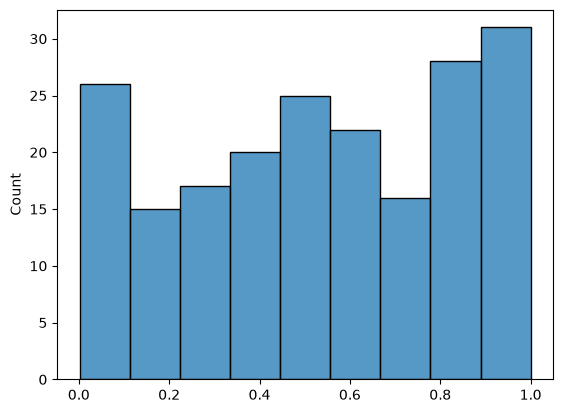

In [9]:
p_values = []
survived_arr = df['survived'].to_numpy()
rng = np.random.default_rng()
for _ in range(200):
    coin = rng.integers(0, 2, size=len(df))
    mask_0 = (coin == 0)
    mask_1 = (coin == 1)
    main_diff = survived_arr[mask_0].mean() - survived_arr[mask_1].mean()
    shuff_surv = survived_arr.copy()
    lines = []
    for _ in range(500):
        rng.shuffle(shuff_surv)
        diff = shuff_surv[mask_0].mean() - shuff_surv[mask_1].mean()
        lines.append(diff)
    lines_arr = np.array(lines)
    p_values.append(np.mean(np.abs(lines_arr) >= np.abs(main_diff)))
df['survived'] = survived_arr
sns.histplot(data=p_values)
print(sum(1 for x in p_values if x < 0.05))

p-value - это вероятность того что мы получим такой же результа или более лучший, при условии что нулевая гипотеза верна

Мощность теста - это его способность обнаружить существующий эффект, мощность растёт с ростом выборки

Для каждого n из [100, 1000, 10000, 100000]:

Возьми по n значений из каждого распределения.
Посчитай p-value для разницы средних. Тут удобнее не перестановки, а готовый инструмент: scipy.stats.ttest_ind — посмотри, что он принимает и что возвращает.
Выведи n, наблюдаемую разницу средних и p-value.

Предскажи до запуска: что будет происходить с p-value по мере роста n? А с самой разницей средних?

Думаю p будет уменшаться по мере роста n, как и разнциа средних

In [10]:
mu1 = 100
mu2 = 100.3
sigma = 15

for n in [100, 1000, 10000, 100000]:

    a = np.random.normal(mu1, sigma, size=n)
    b = np.random.normal(mu2, sigma, size=n)

    mean_diff =np.mean(a) - np.mean(b)

    t, p = stats.ttest_ind(a, b)
    print(mean_diff, p)

2.7927686643976415 0.19527904077785327
0.23251581518620412 0.7310166474647306
0.01379170441811084 0.9485917088880362
-0.24606879453226327 0.0002378302159507907


по выводу может показаться что оба значениея уменьшаются, на самом деле уменьшается только p а разница средних стремится к -0.3 столько же получится если посчитать разницу мю

Также можно сделать вывод что, для того чтобы сравнивать модели нужно отложить для них достаточно большой тест